# 2 — California Housing: regression, learning curves & monotonic constraints

Stage 1 was binary classification. This stage is **regression** — predicting a continuous number (median house value, in $100k units). The remarkable thing is how *little* changes.

### What changes vs. classification
- **Objective:** `reg:squarederror` instead of `binary:logistic`. That swaps the loss, so the gradient/hessian become `g = F − y`, `h = 1` (vs. `g = p − y`, `h = p(1−p)`). See `knowledge/03`.
- **Link function:** *none* (identity). The summed tree score `F(x)` **is** the prediction — no sigmoid (`knowledge/02`).
- **Metrics:** RMSE / MAE / R² instead of logloss / AUC.
- **No stratification** when splitting — that's a classification idea.

### What stays exactly the same
The entire tree-building machinery (`knowledge/04`): histogram splits, the gain formula, leaf weights `w* = −G/(H+λ)`, early stopping, the two APIs. Same engine, different loss.

We'll also demo **monotonic constraints** — encoding domain knowledge like "predicted value must not decrease as income rises."

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgb

from xgblearn.config import ModelConfig, set_global_seed
from xgblearn.data.loaders import load_dataset
from xgblearn.data.splits import train_val_test_split
from xgblearn.models.train import predict_regression, train_native, train_sklearn
from xgblearn.models.evaluate import regression_metrics, plot_residuals, plot_learning_curve

set_global_seed(42)


def pick_device() -> str:
    if not xgb.build_info().get("USE_CUDA", False):
        return "cpu"
    try:
        x = np.random.default_rng(0).random((32, 3), dtype=np.float32)
        d = xgb.QuantileDMatrix(x, label=x[:, 0])
        xgb.train({"device": "cuda", "tree_method": "hist"}, d, num_boost_round=1)
        return "cuda"
    except Exception:
        return "cpu"


DEVICE = pick_device()
print(f"training on: {DEVICE}")

training on: cuda


In [2]:
ds = load_dataset("california_housing")
print(f"{ds.name}: {ds.n_samples} rows x {ds.n_features} features ({ds.task})")
print("target (MedHouseVal, $100k):", ds.y.describe()[["mean", "min", "max"]].round(2).to_dict())
ds.X.head()

california_housing: 20640 rows x 8 features (regression)
target (MedHouseVal, $100k): {'mean': 2.07, 'min': 0.15, 'max': 5.0}


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


## Split (no stratification) and train

Same three-way split discipline, just without `stratify`. Early stopping watches the **last** eval metric (`rmse` here).

In [3]:
splits = train_val_test_split(
    ds.X, ds.y, test_size=0.2, val_size=0.2, stratify=False, seed=42
)
print("sizes:", splits.sizes)

cfg = ModelConfig(
    objective="reg:squarederror",
    eval_metric=["rmse", "mae"],
    device=DEVICE,
    tree_method="hist",
    num_boost_round=1000,
    early_stopping_rounds=50,
    seed=42,
    params={"learning_rate": 0.05, "max_depth": 6, "min_child_weight": 5, "subsample": 0.8},
)
res = train_native(splits, cfg)
print("best_iteration:", res.best_iteration)

sizes: {'train': 13209, 'val': 3303, 'test': 4128}


best_iteration: 999


## Learning curve and residuals

The learning curve (RMSE per round, train vs. val) shows early stopping halting near the validation minimum. The residual plot should be a structureless cloud around zero; structure (a funnel, curvature, a ceiling) reveals what the model is missing.

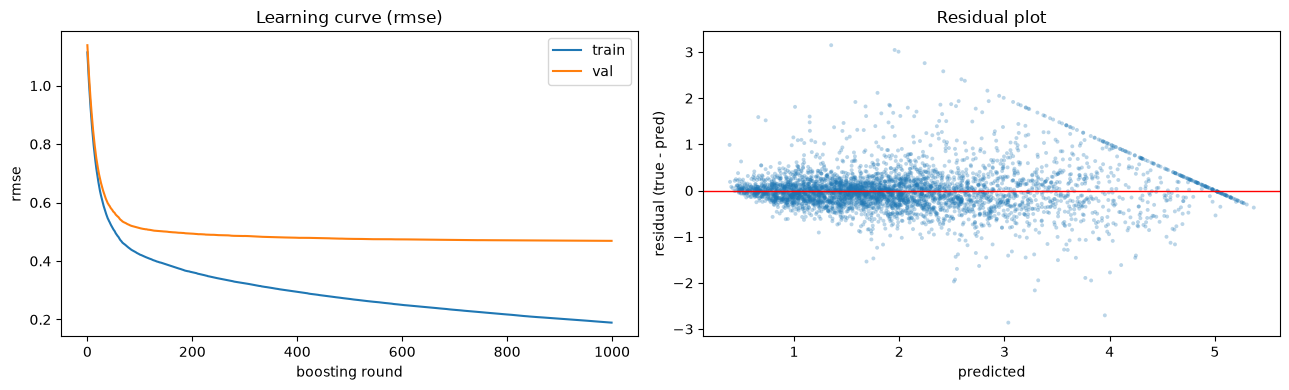

TEST metrics: {'rmse': 0.4438, 'mae': 0.292, 'r2': 0.8497}


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_learning_curve(res.evals_result, metric="rmse", ax=axes[0])

test_pred = predict_regression(res, splits.X_test)
plot_residuals(splits.y_test.to_numpy(), test_pred, ax=axes[1])
plt.tight_layout()
plt.show()

print("TEST metrics:", {k: round(v, 4) for k, v in regression_metrics(splits.y_test.to_numpy(), test_pred).items()})

## Monotonic constraints — encoding domain knowledge

Sometimes you *know* a relationship must go one way: house value should **not decrease** as median income rises, all else equal. A free model can violate this in places — fitting noise produces little non-monotonic wiggles, which is awkward for trust and a non-starter in regulated settings (credit, insurance).

`monotone_constraints={"MedInc": 1}` forces the prediction to be **non-decreasing** in `MedInc` (`-1` would force non-increasing). It works by rejecting any split that would violate the constraint — so it needs `tree_method="hist"` (or `approx`).

We visualize it with a **1-D partial dependence**: vary `MedInc` across its range while holding the other features at their medians, and plot the prediction.

C:\Users\s2608\Documents\sumeet\ml-finetuning\xgboost-lab\.venv\Lib\site-packages\xgboost\core.py:553: UserWarning: [14:34:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


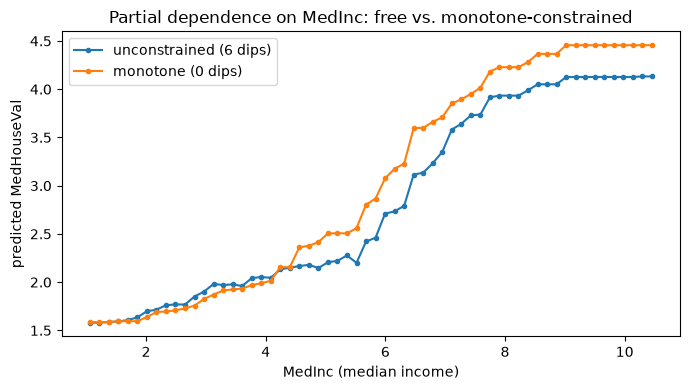

In [5]:
def fit(extra_params):
    c = ModelConfig(
        objective="reg:squarederror", eval_metric=["rmse"], device=DEVICE,
        tree_method="hist", num_boost_round=300, early_stopping_rounds=None, seed=42,
        params={"learning_rate": 0.1, "max_depth": 5, **extra_params},
    )
    return train_sklearn(splits, c)


def partial_dependence_medinc(result, n=60):
    base = splits.X_train.median(numeric_only=True)
    grid = np.linspace(splits.X_train["MedInc"].quantile(0.01),
                       splits.X_train["MedInc"].quantile(0.99), n)
    rows = pd.DataFrame([{**base.to_dict(), "MedInc": v} for v in grid])[splits.X_train.columns]
    return grid, predict_regression(result, rows)


free = fit({})
mono = fit({"monotone_constraints": {"MedInc": 1}})

g1, p_free = partial_dependence_medinc(free)
g2, p_mono = partial_dependence_medinc(mono)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(g1, p_free, label=f"unconstrained ({int((np.diff(p_free) < 0).sum())} dips)", marker=".")
ax.plot(g2, p_mono, label=f"monotone ({int((np.diff(p_mono) < 0).sum())} dips)", marker=".")
ax.set_xlabel("MedInc (median income)")
ax.set_ylabel("predicted MedHouseVal")
ax.set_title("Partial dependence on MedInc: free vs. monotone-constrained")
ax.legend()
plt.tight_layout()
plt.show()

## What to notice (gotchas)

- **Regression reused everything.** Only the objective, link (identity), and metrics changed; the tree machinery is identical to Stage 1.
- **The two APIs still agree** — `train_sklearn` and `train_native` give the same numbers with the same params and seed.
- **Read the residual plot.** A horizontal cloud around zero is healthy. California Housing shows a mild ceiling effect — the target is capped at ~5.0 ($500k), so the model can't predict above it and residuals bunch there.
- **Monotone constraints remove the dips.** The unconstrained curve wiggles downward in places (overfit noise); the constrained curve never decreases. This costs a little flexibility (sometimes a touch of accuracy) in exchange for a guarantee you can defend.
- **`MedInc` dominates** — income is by far the strongest predictor of California house value, which is why it's a natural choice for a monotone constraint.
- **Still no scaling.** Latitude/Longitude, room counts, income — wildly different ranges, zero standardization. Trees don't care (`knowledge/01`).